# <font size="4"> Import dependencies </font>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load and open results.csv
csv_path = "projects/auth/models/YOLO26_6k_frames/YOLO26/results.csv"

df = pd.read_csv(csv_path, sep=';')

df.columns = df.columns.str.strip()

for col in df.columns:
    print(f" - {col}")

df.tail()

FileNotFoundError: [Errno 2] No such file or directory: 'projects/auth/models/YOLO26_6k_frames/YOLO26/results.csv'

# <font size="4"> F1-score </font>

In [4]:
#F1 = 2 * (Precision * Recall)/(Precision + Recall)

P = df['metrics/precision(B)']
R = df['metrics/recall(B)']
F1 = 2 * ((P*R)/(P+R))
df['metrics/F1-score'] = F1.round(4)
df.tail()


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,...,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,lr/pg3,lr/pg4,lr/pg5,lr/pg6,lr/pg7,metrics/F1-score
82,83,3532.95,1.30831,0.61785,0.00376,0.76724,0.64699,0.64813,0.42775,1.62660,...,0.00560,0.013764,0.004588,0.013764,0.004588,0.013764,0.004588,0.013764,0.004588,0.7020
83,84,3574.62,1.30262,0.61371,0.00365,0.76952,0.64555,0.64585,0.42589,1.63145,...,0.00561,0.013566,0.004522,0.013566,0.004522,0.013566,0.004522,0.013566,0.004522,0.7021
84,85,3616.36,1.29288,0.61637,0.00364,0.78092,0.63164,0.64309,0.42293,1.62683,...,0.00564,0.013368,0.004456,0.013368,0.004456,0.013368,0.004456,0.013368,0.004456,0.6984
85,86,3658.09,1.30198,0.61705,0.00364,0.78255,0.62649,0.63636,0.41754,1.62208,...,0.00560,0.013170,0.004390,0.013170,0.004390,0.013170,0.004390,0.013170,0.004390,0.6959
86,87,3700.07,1.28426,0.60097,0.00364,0.78570,0.63404,0.64543,0.42182,1.62731,...,0.00548,0.012972,0.004324,0.012972,0.004324,0.012972,0.004324,0.012972,0.004324,0.7018


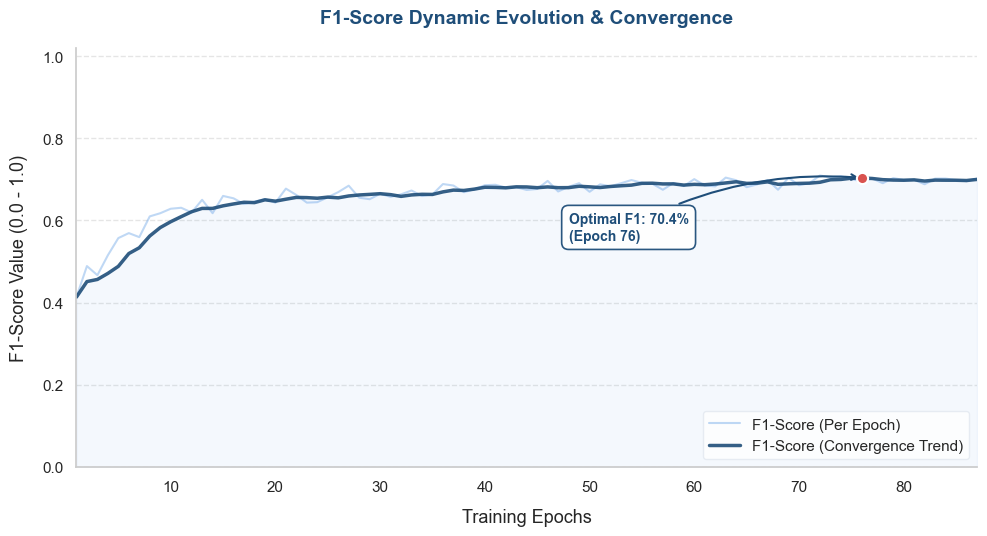

In [5]:

# 1. Compute Moving Average (5-epoch window) for curve smoothing
df['metrics/F1-score_smooth'] = df['metrics/F1-score'].rolling(window=5, min_periods=1).mean()

# 2. Set academic publication style
sns.set_theme(style="white")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'font.family': 'sans-serif'
})

fig, ax = plt.subplots(figsize=(10, 5.5))

# Add soft horizontal gridlines only
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax.xaxis.grid(False)

# 3. Plot raw epoch-by-epoch F1 curve (semi-transparent)
ax.plot(df['epoch'], df['metrics/F1-score'], color='#4a90e2', alpha=0.35, linewidth=1.5, label='F1-Score (Per Epoch)')

# 4. Plot smoothed trendline (bold)
ax.plot(df['epoch'], df['metrics/F1-score_smooth'], color='#1f4e79', alpha=0.9, linewidth=2.5, label='F1-Score (Convergence Trend)')

# 5. Add a very soft color gradient fill underneath
ax.fill_between(df['epoch'], df['metrics/F1-score_smooth'], color='#4a90e2', alpha=0.06)

# 6. Locate peak performance based on the stable smoothed line
max_f1 = df['metrics/F1-score_smooth'].max()
smooth_col = 'metrics/f1_score_smooth' if 'metrics/f1_score_smooth' in df.columns else 'metrics/F1-score_smooth'
max_epoch = df.loc[df[smooth_col].idxmax(), 'epoch']

# Draw the peak value dot
ax.scatter(max_epoch, max_f1, color='#d9534f', s=65, zorder=5, edgecolor='white', linewidth=1.5)

# Minimalist callout box for the Best Metric
ax.annotate(
    f'Optimal F1: {max_f1*100:.1f}%\n(Epoch {max_epoch})',
    xy=(max_epoch, max_f1),
    xytext=(max_epoch - 28, max_f1 - 0.15),
    bbox=dict(boxstyle="round,pad=0.5", fc="#ffffff", ec="#1f4e79", lw=1.2, alpha=0.95),
    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=-0.15", color="#1f4e79", lw=1.5),
    fontweight='bold',
    fontsize=10,
    color='#1f4e79'
)

# English Titles and Labels
ax.set_title('F1-Score Dynamic Evolution & Convergence', pad=18, fontweight='bold', color='#1f4e79')
ax.set_xlabel('Training Epochs', labelpad=10)
ax.set_ylabel('F1-Score Value (0.0 - 1.0)', labelpad=10)

# Clean up axes spines for a modern look
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#cccccc')

ax.set_ylim(0, 1.02)
ax.set_xlim(df['epoch'].min(), df['epoch'].max())

# Elegant Legend
ax.legend(loc='lower right', frameon=True, facecolor='#ffffff', edgecolor='#e2e8f0')

plt.tight_layout()

plt.show()

# <font size="4"> Recall & Precision </font>

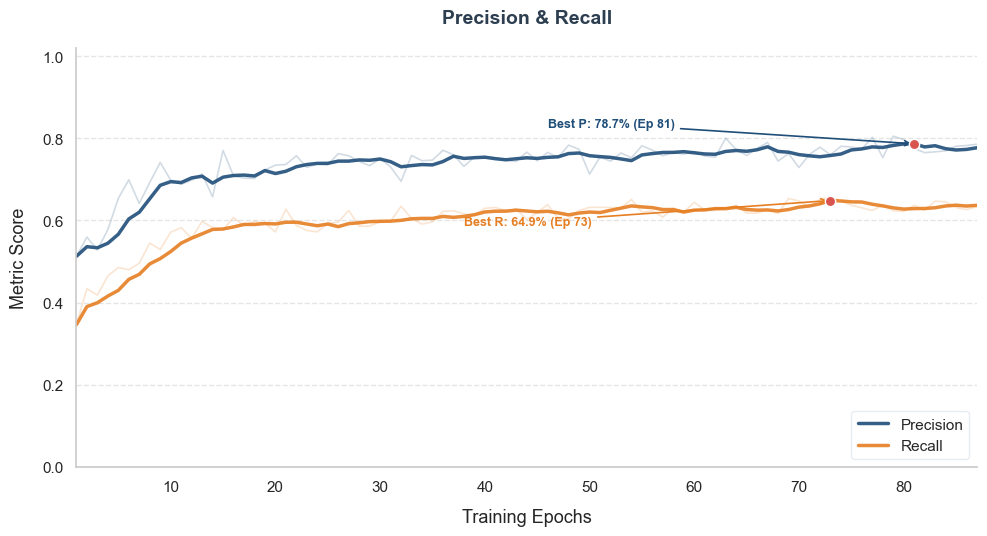

In [6]:
# 1. Compute moving averages (5-epoch window) for smooth visualization
df['metrics/precision_smooth'] = df['metrics/precision(B)'].rolling(window=5, min_periods=1).mean()
df['metrics/recall_smooth'] = df['metrics/recall(B)'].rolling(window=5, min_periods=1).mean()

# 2. Set style settings for clean publication look
sns.set_theme(style="white")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'font.family': 'sans-serif'
})

fig, ax = plt.subplots(figsize=(10, 5.5))

# Soft horizontal gridlines
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax.xaxis.grid(False)

# Colors for our metrics
color_prec = '#1f4e79'  # Deep Blue
color_rec = '#e67e22'   # Coral / Orange

# 3. Plot Precision (Raw & Smoothed)
ax.plot(df['epoch'], df['metrics/precision(B)'], color=color_prec, alpha=0.2, linewidth=1.2)
ax.plot(df['epoch'], df['metrics/precision_smooth'], color=color_prec, alpha=0.9, linewidth=2.5, label='Precision')

# 4. Plot Recall (Raw & Smoothed)
ax.plot(df['epoch'], df['metrics/recall(B)'], color=color_rec, alpha=0.2, linewidth=1.2)
ax.plot(df['epoch'], df['metrics/recall_smooth'], color=color_rec, alpha=0.9, linewidth=2.5, label='Recall')

# 5. Locate Optimal Max Epochs for both metrics
max_p = df['metrics/precision_smooth'].max()
max_p_epoch = df.loc[df['metrics/precision_smooth'].idxmax(), 'epoch']

max_r = df['metrics/recall_smooth'].max()
max_r_epoch = df.loc[df['metrics/recall_smooth'].idxmax(), 'epoch']

# Highlight optimal points with dots
ax.scatter(max_p_epoch, max_p, color='#d9534f', s=55, zorder=5, edgecolor='white')
ax.scatter(max_r_epoch, max_r, color='#d9534f', s=55, zorder=5, edgecolor='white')

# Dynamic annotations for the optimal values
ax.annotate(f'Best P: {max_p*100:.1f}% (Ep {max_p_epoch})', 
            xy=(max_p_epoch, max_p), xytext=(max_p_epoch - 35, max_p + 0.04),
            arrowprops=dict(arrowstyle="->", color=color_prec, lw=1.2),
            fontweight='bold', fontsize=9, color=color_prec)

ax.annotate(f'Best R: {max_r*100:.1f}% (Ep {max_r_epoch})', 
            xy=(max_r_epoch, max_r), xytext=(max_r_epoch - 35, max_r - 0.06),
            arrowprops=dict(arrowstyle="->", color=color_rec, lw=1.2),
            fontweight='bold', fontsize=9, color=color_rec)

# Labels & Titles (Single Y-axis focus)
ax.set_title('Precision & Recall', pad=18, fontweight='bold', color='#2c3e50')
ax.set_xlabel('Training Epochs', labelpad=10)
ax.set_ylabel('Metric Score', labelpad=10)

# Clean up layout borders
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#cccccc')

ax.set_ylim(0, 1.02)
ax.set_xlim(df['epoch'].min(), df['epoch'].max())

# Unified clean Legend
ax.legend(loc='lower right', frameon=True, facecolor='#ffffff', edgecolor='#e2e8f0')

plt.tight_layout()

plt.show()

# <font size="4"> Overfitting check </font>

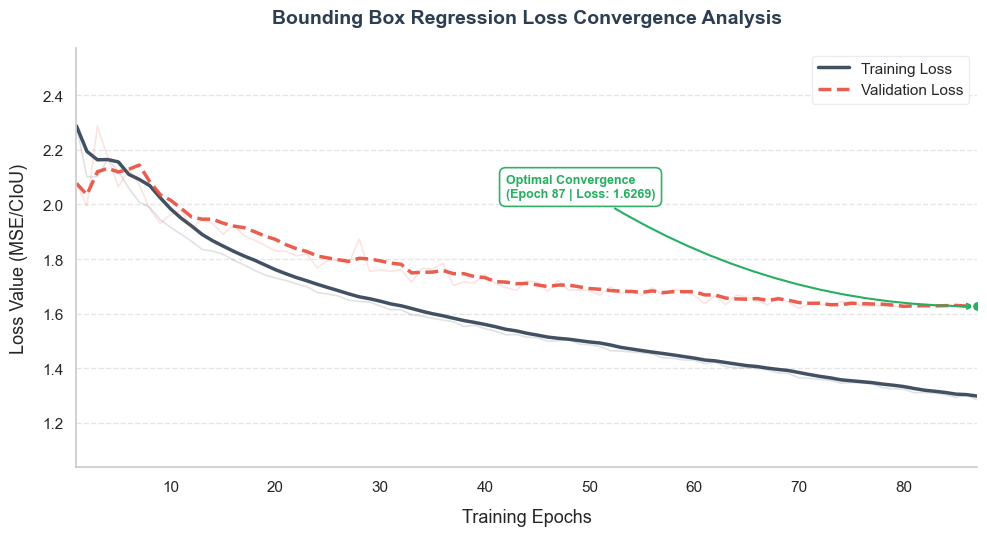

In [7]:
# 1. Compute moving averages (5-epoch window) for smooth visualization of trends
df['train/box_loss_smooth'] = df['train/box_loss'].rolling(window=5, min_periods=1).mean()
df['val/box_loss_smooth'] = df['val/box_loss'].rolling(window=5, min_periods=1).mean()

# 2. Set academic style settings
sns.set_theme(style="white")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'font.family': 'sans-serif'
})

fig, ax = plt.subplots(figsize=(10, 5.5))

# Soft horizontal gridlines
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax.xaxis.grid(False)

# Theme colors
color_train = '#2c3e50'  # Dark Slate Blue/Grey for Training
color_val = '#e74c3c'    # Bright Red/Coral for Validation

# 3. Plot Training Box Loss (Raw as light background, Smoothed as bold line)
ax.plot(df['epoch'], df['train/box_loss'], color=color_train, alpha=0.15, linewidth=1.2)
ax.plot(df['epoch'], df['train/box_loss_smooth'], color=color_train, alpha=0.9, linewidth=2.5, label='Training Loss')

# 4. Plot Validation Box Loss (Raw as light background, Smoothed as bold dashed line)
ax.plot(df['epoch'], df['val/box_loss'], color=color_val, alpha=0.15, linewidth=1.2)
ax.plot(df['epoch'], df['val/box_loss_smooth'], color=color_val, alpha=0.9, linewidth=2.5, linestyle='--', label='Validation Loss')

# 5. Find the minimum Validation Loss point to showcase optimal convergence
min_val_loss = df['val/box_loss_smooth'].min()
min_val_epoch = df.loc[df['val/box_loss_smooth'].idxmax() if 'val/box_loss_smooth' not in df.columns else df['val/box_loss_smooth'].idxmin(), 'epoch']

# Highlight the lowest validation loss point
ax.scatter(min_val_epoch, min_val_loss, color='#27ae60', s=60, zorder=5, edgecolor='white', linewidth=1.5)

# Minimalist callout box for the point of optimal convergence
ax.annotate(
    f'Optimal Convergence\n(Epoch {min_val_epoch} | Loss: {min_val_loss:.4f})',
    xy=(min_val_epoch, min_val_loss),
    xytext=(min_val_epoch - 45, min_val_loss + 0.4),
    bbox=dict(boxstyle="round,pad=0.5", fc="#ffffff", ec="#27ae60", lw=1.2, alpha=0.95),
    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.15", color="#27ae60", lw=1.5),
    fontweight='bold',
    fontsize=9,
    color='#27ae60'
)

# Titles, Labels, and Layout constraints
ax.set_title('Bounding Box Regression Loss Convergence Analysis', pad=18, fontweight='bold', color='#2c3e50')
ax.set_xlabel('Training Epochs', labelpad=10)
ax.set_ylabel('Loss Value (MSE/CIoU)', labelpad=10)

# Clean up axes spines for a modern look
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#cccccc')

ax.set_xlim(df['epoch'].min(), df['epoch'].max())

# Adjust Y-limits automatically with a bit of padding to avoid cutting off annotations
ax.set_ylim(df['train/box_loss_smooth'].min() * 0.8, df['val/box_loss_smooth'].max() * 1.2)

# Unified clean Legend
ax.legend(loc='upper right', frameon=True, facecolor='#ffffff', edgecolor='#e2e8f0')

plt.tight_layout()

plt.show()

# <font size="4"> mAP50 </font>

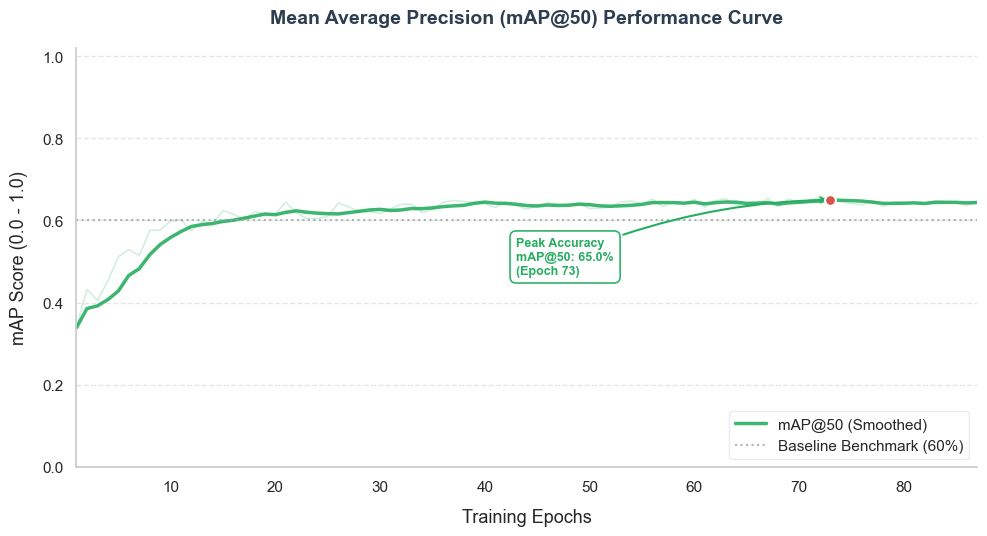

In [8]:
# 1. Compute moving average for mAP50
df['metrics/mAP50_smooth'] = df['metrics/mAP50(B)'].rolling(window=5, min_periods=1).mean()

# 2. Style configuration
sns.set_theme(style="white")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'font.family': 'sans-serif'
})

fig, ax = plt.subplots(figsize=(10, 5.5))

# Soft background grids
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax.xaxis.grid(False)

# Theme color for mAP (Emerald Green is great for success metrics)
color_map = '#27ae60'

# 3. Plot raw and smoothed mAP50 curves
ax.plot(df['epoch'], df['metrics/mAP50(B)'], color=color_map, alpha=0.2, linewidth=1.2)
ax.plot(df['epoch'], df['metrics/mAP50_smooth'], color=color_map, alpha=0.9, linewidth=2.5, label='mAP@50 (Smoothed)')

# 4. Add an academic benchmark line (e.g., 60% mark typical for acceptable baseline)
benchmark_val = 0.60
ax.axhline(y=benchmark_val, color='#95a5a6', linestyle=':', alpha=0.8, linewidth=1.5, label=f'Baseline Benchmark ({benchmark_val*100:.0f}%)')

# 5. Locate the absolute highest mAP50 peak
max_map = df['metrics/mAP50_smooth'].max()
max_map_epoch = df.loc[df['metrics/mAP50_smooth'].idxmax(), 'epoch']

# Draw peak indicator
ax.scatter(max_map_epoch, max_map, color='#d9534f', s=60, zorder=5, edgecolor='white', linewidth=1.5)

# Callout annotation text box
ax.annotate(
    f'Peak Accuracy\nmAP@50: {max_map*100:.1f}%\n(Epoch {max_map_epoch})',
    xy=(max_map_epoch, max_map),
    xytext=(max_map_epoch - 30, max_map - 0.18),
    bbox=dict(boxstyle="round,pad=0.5", fc="#ffffff", ec=color_map, lw=1.2, alpha=0.95),
    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=-0.1", color=color_map, lw=1.5),
    fontweight='bold',
    fontsize=9,
    color=color_map
)

# Titles, Labels, Spine cleanup
ax.set_title('Mean Average Precision (mAP@50) Performance Curve', pad=18, fontweight='bold', color='#2c3e50')
ax.set_xlabel('Training Epochs', labelpad=10)
ax.set_ylabel('mAP Score (0.0 - 1.0)', labelpad=10)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#cccccc')

ax.set_ylim(0, 1.02)
ax.set_xlim(df['epoch'].min(), df['epoch'].max())

# Legend
ax.legend(loc='lower right', frameon=True, facecolor='#ffffff', edgecolor='#e2e8f0')

plt.tight_layout()
plt.show()

# <font size="4"> mAP50-95 </font>

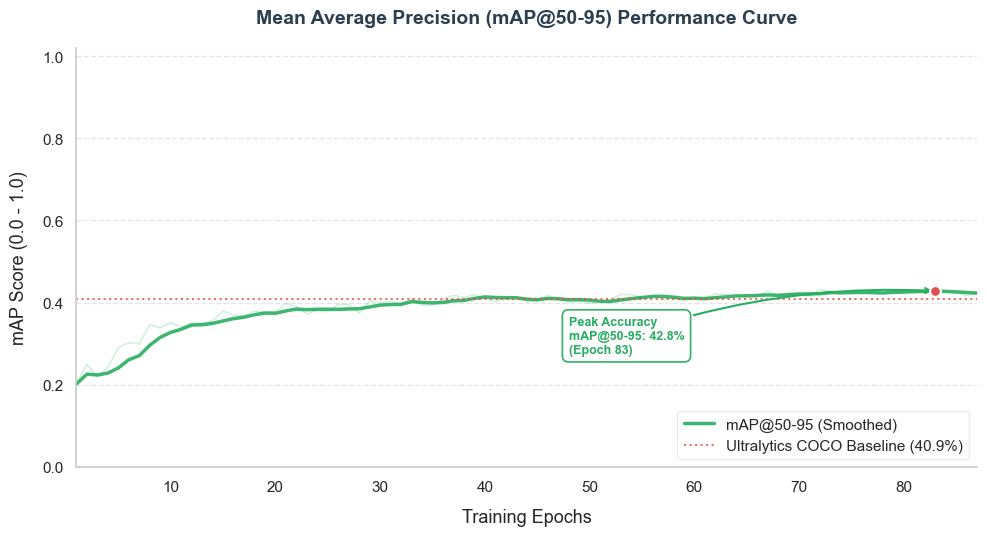

In [ ]:
# 1. Calculate moving average for mAP50-95
df['metrics/mAP5095_smooth'] = df['metrics/mAP50-95(B)'].rolling(window=5, min_periods=1).mean()

# 2. Appearance settings (Style)
sns.set_theme(style="white")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'font.family': 'sans-serif'
})

fig, ax = plt.subplots(figsize=(10, 5.5))

# Soft background grid
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax.xaxis.grid(False)

# Color for mAP (Emerald Green indicates success in academic plots)
color_map = '#27ae60'

# 3. Drawing the curve (Raw and Smoothed)
ax.plot(df['epoch'], df['metrics/mAP50-95(B)'], color=color_map, alpha=0.2, linewidth=1.2)
ax.plot(df['epoch'], df['metrics/mAP5095_smooth'], color=color_map, alpha=0.9, linewidth=2.5, label='mAP@50-95 (Smoothed)')

# 4. Add the official Ultralytics COCO Baseline (40.9%)
benchmark_val = 0.409
ax.axhline(y=benchmark_val, color='#e74c3c', linestyle=':', alpha=0.8, linewidth=1.5, label=f'Ultralytics COCO Baseline ({benchmark_val*100:.1f}%)')

# 5. Locate the absolute maximum (Peak)
max_map = df['metrics/mAP5095_smooth'].max()
max_map_epoch = df.loc[df['metrics/mAP5095_smooth'].idxmax(), 'epoch']

# Dot at the maximum peak
ax.scatter(max_map_epoch, max_map, color='#d9534f', s=60, zorder=5, edgecolor='white', linewidth=1.5)

# Annotation Callout Box
ax.annotate(
    f'Peak Accuracy\nmAP@50-95: {max_map*100:.1f}%\n(Epoch {max_map_epoch})',
    xy=(max_map_epoch, max_map),
    xytext=(max_map_epoch - 35, max_map - 0.15), # Adjusted position to be clearly visible
    bbox=dict(boxstyle="round,pad=0.5", fc="#ffffff", ec=color_map, lw=1.2, alpha=0.95),
    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=-0.1", color=color_map, lw=1.5),
    fontweight='bold',
    fontsize=9,
    color=color_map
)

# Titles, Labels and axes cleanup
ax.set_title('Mean Average Precision (mAP@50-95) Performance Curve', pad=18, fontweight='bold', color='#2c3e50')
ax.set_xlabel('Training Epochs', labelpad=10)
ax.set_ylabel('mAP Score (0.0 - 1.0)', labelpad=10)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#cccccc')

# Axes limits
ax.set_ylim(0, 1.02)
ax.set_xlim(df['epoch'].min(), df['epoch'].max())

# Legend
ax.legend(loc='lower right', frameon=True, facecolor='#ffffff', edgecolor='#e2e8f0')

plt.tight_layout()
plt.show()